# **Data Practicum II**

**Investigating the Co-occurrence of Supply Chain Gaps that are Driven by Business Closures in the US**

### Week 7: Cross-Sectoral Co-occurrence Network (Closure vs. Entry)


##**Data Loading**

In [ ]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("df_merged.csv")

orig_shape = df.shape

# Filtering for years greater than 1999
numeric = pd.to_numeric(df['year'], errors='coerce')
year_int = numeric.where((numeric >= 1900) & (numeric <= 2100)).astype('Int64')
df['year'] = year_int
df = df[df['year'].notna() & (df['year'] > 1999)].copy()

# Converting the 'year' column to datetime for downstream operations
df['year'] = pd.to_datetime(df['year'].astype(int).astype(str) + '-01-01')

print(f"Original shape: {orig_shape}, after filtering year > 1999: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Original shape: (436636, 33), after filtering year > 1999: (227859, 33)
Columns: ['Unnamed: 0', 'year', 'st', 'sector', 'fage', 'firms', 'estabs', 'emp', 'denom', 'estabs_entry', 'estabs_entry_rate', 'estabs_exit', 'estabs_exit_rate', 'job_creation', 'job_creation_births', 'job_creation_continuers', 'job_creation_rate_births', 'job_creation_rate', 'job_destruction', 'job_destruction_deaths', 'job_destruction_continuers', 'job_destruction_rate_deaths', 'job_destruction_rate', 'net_job_creation', 'net_job_creation_rate', 'reallocation_rate', 'firmdeath_firms', 'firmdeath_estabs', 'firmdeath_emp', 'sector_name', 'state_abbr', 'income', 'population']


,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,net_job_creation,net_job_creation_rate,reallocation_rate,firmdeath_firms,firmdeath_estabs,firmdeath_emp,sector_name,state_abbr,income,population
22,22,2000-01-01,1,11,b) 1,45.0,45.0,290.0,347.0,0.0,...,-113.0,-32.564841,32.276657,18.0,18.0,151.0,"Agriculture, Forestry, Fishing and Hunting",AL,60570.0,4452.173
23,23,2001-01-01,1,11,b) 1,48.0,48.0,345.0,367.0,0.0,...,-44.0,-11.989101,25.068120,16.0,16.0,60.0,"Agriculture, Forestry, Fishing and Hunting",AL,58790.0,4467.634
24,24,2002-01-01,1,11,b) 1,30.0,31.0,108.0,115.0,0.0,...,-16.0,-13.913043,29.565217,4.0,4.0,11.0,"Agriculture, Forestry, Fishing and Hunting",AL,62100.0,4480.089
25,25,2003-01-01,1,11,b) 1,34.0,34.0,208.0,231.0,0.0,...,-46.0,-19.913420,30.303030,8.0,8.0,20.0,"Agriculture, Forestry, Fishing and Hunting",AL,60270.0,4503.491
26,26,2004-01-01,1,11,b) 1,28.0,28.0,108.0,112.0,0.0,...,-6.0,-5.357143,55.357143,9.0,9.0,23.0,"Agriculture, Forestry, Fishing and Hunting",AL,57810.0,4530.729


In [ ]:
# Checking for missing values
print("\nMissing values per column (only columns with missing data):")
missing = df.isna().sum()
print(missing[missing > 0])


Missing values per column (only columns with missing data):
Series([], dtype: int64)


## **Feature Engineering**

Features engineering focused on **sector-level business closures** that drive supply chain gaps. The metrics relate to firm and establishment deaths, labor market dynamics, and growth momentum—all grouped by sector and state to preserve the panel structure critical for supply chain analysis.

In [ ]:
import numpy as np

df = df.copy()

# Preparing primary closure targets
df['closure_target'] = df['firmdeath_firms']
df['closure_rate'] = df['firmdeath_estabs'] / df['estabs']  # Calculating normalized establishment death rate
df['closure_rate_firms'] = df['firmdeath_firms'] / df['firms']  # Calculating normalized firm death rate

# Creating labor market stress and density indicators
df['employment_density'] = df['emp'] / df['population']
df['job_destruction_intensity'] = df['job_destruction'] / df['emp']

# Sorting data by panel structure: sector and state
group_cols = ['state_abbr', 'sector_name']
df = df.sort_values(group_cols + ['year'])

print("Closure targets and core metrics created:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_target', 'closure_rate',
          'job_destruction_rate', 'employment_density']].head(10))

Closure targets and core metrics created:
      state_abbr                      sector_name       year  closure_target  \
17855         AK  Accommodation and Food Services 2000-01-01            39.0   
17901         AK  Accommodation and Food Services 2000-01-01            14.0   
17947         AK  Accommodation and Food Services 2000-01-01            14.0   
17993         AK  Accommodation and Food Services 2000-01-01             8.0   
18039         AK  Accommodation and Food Services 2000-01-01             6.0   
18085         AK  Accommodation and Food Services 2000-01-01            12.0   
18131         AK  Accommodation and Food Services 2000-01-01            15.0   
18177         AK  Accommodation and Food Services 2000-01-01             6.0   
18223         AK  Accommodation and Food Services 2000-01-01             3.0   
18269         AK  Accommodation and Food Services 2000-01-01             0.0   

       closure_rate  job_destruction_rate  employment_density  
17855      0.

In [ ]:
# Engineering temporal lag features by sector
# Adding lagged features, which capture historical dependencies critical for LSTM sequence modeling

lag_features = ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
group_cols = ['state_abbr', 'sector_name']

for col in lag_features:
    for lag in [1, 2]:
        df[f'lag{lag}_{col}'] = df.groupby(group_cols)[col].shift(lag)

print(f"Lagged features created for {lag_features}")
print(f"Total lag features: {len(lag_features) * 2}")
print("\nSample lagged features:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_rate', 'lag1_closure_rate',
          'lag2_closure_rate', 'job_destruction_rate', 'lag1_job_destruction_rate']].head(15))

Lagged features created for ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
Total lag features: 8

Sample lagged features:
      state_abbr                      sector_name       year  closure_rate  \
17855         AK  Accommodation and Food Services 2000-01-01      0.402062   
17901         AK  Accommodation and Food Services 2000-01-01      0.194444   
17947         AK  Accommodation and Food Services 2000-01-01      0.177215   
17993         AK  Accommodation and Food Services 2000-01-01      0.097561   
18039         AK  Accommodation and Food Services 2000-01-01      0.076923   
18085         AK  Accommodation and Food Services 2000-01-01      0.053571   
18131         AK  Accommodation and Food Services 2000-01-01      0.087156   
18177         AK  Accommodation and Food Services 2000-01-01      0.040541   
18223         AK  Accommodation and Food Services 2000-01-01      0.029703   
18269         AK  Accommodation and Food Services 2000-01-

In [ ]:
# Engineering derived features, including moving averages and growth rates by sector
# Capturing momentum and cyclical patterns in closure risk within sectors

# Calculating 3-year rolling averages to smooth short-term volatility and reveal trends
df['ma3_closure_rate'] = df.groupby(group_cols)['closure_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['ma3_job_destruction_rate'] = df.groupby(group_cols)['job_destruction_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Calculating year-over-year growth rates, capturing macro and sector momentum
df['income_yoy'] = df.groupby(group_cols)['income'].pct_change()
df['population_yoy'] = df.groupby(group_cols)['population'].pct_change()
df['employment_yoy'] = df.groupby(group_cols)['emp'].pct_change()

print("Derived features created:")
print("  - 3-year moving average for closure_rate and job_destruction_rate")
print("  - Year-over-year growth rates: income, population, employment")
print("\nSample derived features by sector:")
sample_sector = df[df['sector_name'].str.contains('Retail', na=False)].drop_duplicates('year').head(10)
print(sample_sector[['sector_name', 'year', 'closure_rate', 'ma3_closure_rate',
                      'income_yoy', 'population_yoy', 'employment_yoy']].to_string())

Derived features created:
  - 3-year moving average for closure_rate and job_destruction_rate
  - Year-over-year growth rates: income, population, employment

Sample derived features by sector:
        sector_name       year  closure_rate  ma3_closure_rate  income_yoy  population_yoy  employment_yoy
12427  Retail Trade 2000-01-01      0.359551          0.359551         NaN             NaN             NaN
12428  Retail Trade 2001-01-01      0.333333          0.135643    0.061532        0.009158       -0.978255
12429  Retail Trade 2002-01-01      0.217822          0.098071   -0.091326        0.013607       -0.979359
12430  Retail Trade 2003-01-01      0.231405          0.106672   -0.037861        0.009461       -0.954680
12431  Retail Trade 2004-01-01      0.230769          0.098068    0.036251        0.016767       -0.978248
12432  Retail Trade 2005-01-01      0.346535          0.133296   -0.013464        0.011619       -0.974861
12433  Retail Trade 2006-01-01      0.345238          0.1

In [ ]:
# Dropping NaNs due to lagging
df = df.dropna()
df.head()

,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,lag2_job_destruction_rate,lag1_reallocation_rate,lag2_reallocation_rate,lag1_net_job_creation_rate,lag2_net_job_creation_rate,ma3_closure_rate,ma3_job_destruction_rate,income_yoy,population_yoy,employment_yoy
17947,17947,2000-01-01,2,72,d) 3,78.0,79.0,725.0,761.0,3.0,...,35.384615,29.274966,55.897436,-32.558140,-7.435897,0.257907,35.630119,0.0,0.0,0.180782
17993,17993,2000-01-01,2,72,e) 4,79.0,82.0,885.0,809.0,8.0,...,47.195622,30.749014,29.274966,-8.935611,-32.558140,0.156407,26.925482,0.0,0.0,0.220690
18039,18039,2000-01-01,2,72,f) 5,70.0,78.0,1062.0,1060.0,3.0,...,24.310118,18.541409,30.749014,19.653894,-8.935611,0.117233,17.294237,0.0,0.0,0.200000
18085,18085,2000-01-01,2,72,g) 6 to 10,208.0,224.0,2784.0,2880.0,10.0,...,9.270705,33.144654,18.541409,-1.729560,19.653894,0.076018,16.771882,0.0,0.0,1.621469
18131,18131,2000-01-01,2,72,h) 11 to 15,180.0,218.0,3358.0,3431.0,16.0,...,18.301887,31.041667,33.144654,-7.222222,-1.729560,0.072550,20.608685,0.0,0.0,0.206178


In [ ]:
# Preparing a feature summary table and conducting correlation analysis

feature_table = pd.DataFrame([
    ['closure_target', 'Firm deaths (count)', 'Actual business closures in sector'],
    ['closure_rate', 'Estab. deaths / Estabs', 'Normalized closure intensity by sector'],
    ['closure_rate_firms', 'Firm deaths / Firms', 'Firm-level closure intensity by sector'],
    ['job_destruction_rate', 'Job destruction rate', 'Labor market stress leading indicator'],
    ['net_job_creation_rate', 'Net job creation rate', 'Sector labor market momentum'],
    ['reallocation_rate', 'Reallocation rate', 'Structural churn within sector'],
    ['lag1_closure_rate', 'Previous-year closure rate', 'LSTM temporal dependency (t-1)'],
    ['lag2_closure_rate', 'Prior 2-year closure rate', 'LSTM temporal dependency (t-2)'],
    ['ma3_closure_rate', '3-year MA of closure rate', 'Smoothed trend in sector closures'],
    ['income', 'Median income', 'Proxy for local demand in sector'],
    ['population', 'Population', 'Market size and labor pool'],
    ['income_yoy', 'Income growth (YoY)', 'Demand momentum by sector'],
    ['population_yoy', 'Population growth (YoY)', 'Demographic momentum'],
    ['employment_density', 'Employment / population', 'Sector concentration in local area'],
], columns=['feature', 'definition', 'supply chain relevance'])

print("Selected Features for Sector-Level Closure Prediction:")
display(feature_table)

Selected Features for Sector-Level Closure Prediction:


,feature,definition,supply chain relevance
0,closure_target,Firm deaths (count),Actual business closures in sector
1,closure_rate,Estab. deaths / Estabs,Normalized closure intensity by sector
2,closure_rate_firms,Firm deaths / Firms,Firm-level closure intensity by sector
3,job_destruction_rate,Job destruction rate,Labor market stress leading indicator
4,net_job_creation_rate,Net job creation rate,Sector labor market momentum
5,reallocation_rate,Reallocation rate,Structural churn within sector
6,lag1_closure_rate,Previous-year closure rate,LSTM temporal dependency (t-1)
7,lag2_closure_rate,Prior 2-year closure rate,LSTM temporal dependency (t-2)
8,ma3_closure_rate,3-year MA of closure rate,Smoothed trend in sector closures
9,income,Median income,Proxy for local demand in sector


### **Cross-Sectoral Co-occurrence Network: Closure Rate vs. Establishment Entry Rate**

This analysis visualizes the co-movement between the business closure rate of one sector and the business establishment entry rate of another. An edge between Sector A and Sector B signifies a strong positive correlation where an increase in Sector A's closure rate is associated with an increase in Sector B's establishment entry rate. This helps to identify inter-sectoral dependencies and potential cascading effects in supply chains where distress in one area might paradoxically coincide with growth in another.

*   **Edges:** Represent strong positive correlations between a source sector's closure rate and a target sector's establishment entry rate. The **thickness of the edge indicates the strength of this correlation**, with thicker edges signifying stronger co-movement.
*   **Nodes:** Represent individual sectors, labeled by their 2-digit NAICS codes. The **size of each sector's node reflects its total sum of firm deaths** over the years included in the analysis.
*   **Colors:** Sectors are grouped and colored by detected communities, highlighting clusters of sectors that exhibit similar relational behaviors.

In [ ]:
# 1. Prepare sector-level time series data for closure_rate and estabs_entry_rate
closure_rate_panel = df.groupby(['year', 'sector_name'])['closure_rate'].mean().unstack()
estabs_entry_rate_panel = df.groupby(['year', 'sector_name'])['estabs_entry_rate'].mean().unstack()

# Ensure both panels have the same columns (sectors) and index (years)
common_sectors = list(set(closure_rate_panel.columns) & set(estabs_entry_rate_panel.columns))
closure_rate_panel = closure_rate_panel[common_sectors]
estabs_entry_rate_panel = estabs_entry_rate_panel[common_sectors]

# 2. Calculate the cross-sectoral correlation matrix (closure_rate of sector A vs. estabs_entry_rate of sector B)
corr_matrix_closure_entry = pd.DataFrame(
    index=common_sectors,
    columns=common_sectors
)

for sector_a in common_sectors:
    for sector_b in common_sectors:
        # Calculate correlation between closure_rate of sector A and estabs_entry_rate of sector B
        # Drop NaNs before calculating correlation, as some time series might have missing values
        combined_series = pd.DataFrame({
            'closure_a': closure_rate_panel[sector_a],
            'entry_b': estabs_entry_rate_panel[sector_b]
        }).dropna()

        if len(combined_series) > 1: # Need at least 2 data points for correlation
            corr_val = combined_series['closure_a'].corr(combined_series['entry_b'], method='pearson')
            corr_matrix_closure_entry.loc[sector_a, sector_b] = corr_val
        else:
            corr_matrix_closure_entry.loc[sector_a, sector_b] = np.nan

print("Cross-Sectoral Correlation Matrix (Closure Rate vs. Establishment Entry Rate) - First 5x5:")
display(corr_matrix_closure_entry.head())

Cross-Sectoral Correlation Matrix (Closure Rate vs. Establishment Entry Rate) - First 5x5:


,Transportation and Warehousing,Real Estate and Rental and Leasing,Construction,Utilities,Health Care and Social Assistance,"Mining, Quarrying, and Oil and Gas Extraction",Wholesale Trade,"Professional, Scientific, and Technical Services",Finance and Insurance,"Arts, Entertainment, and Recreation",Educational Services,Administrative and Support and Waste Management and Remediation Services,Other Services (except Public Administration),Information,"Agriculture, Forestry, Fishing and Hunting",Accommodation and Food Services,Management of Companies and Enterprises,Manufacturing,Retail Trade
Transportation and Warehousing,0.089449,-0.052507,-0.249762,-0.054464,0.130218,0.165738,0.248591,-0.044208,0.062103,0.172996,0.359691,-0.039333,0.211164,0.031792,0.203593,0.235036,0.104681,0.106485,0.15531
Real Estate and Rental and Leasing,0.101157,-0.063939,-0.163053,-0.021664,-0.12002,0.009685,0.292762,-0.085137,-0.01257,0.038859,0.304925,0.105967,0.06697,-0.01967,0.150504,0.133356,0.231957,-0.018676,0.089649
Construction,-0.054834,-0.037793,0.090816,-0.14109,-0.372586,-0.240761,0.037067,-0.050982,-0.189661,-0.16423,0.08923,0.051482,-0.131593,-0.213079,0.350796,-0.081391,0.144887,-0.179176,-0.108797
Utilities,0.413814,0.180358,-0.321468,0.286745,0.602669,0.551314,0.512992,0.183508,0.442896,0.507949,0.416891,-0.077896,0.580892,0.43383,0.056637,0.618108,0.036133,0.503254,0.551236
Health Care and Social Assistance,-0.090515,-0.301844,-0.179068,0.076774,0.29635,0.487409,0.008547,0.007901,-0.328357,0.332362,0.303831,-0.04458,0.273996,-0.13499,-0.430115,-0.208785,-0.545847,0.298835,-0.12812


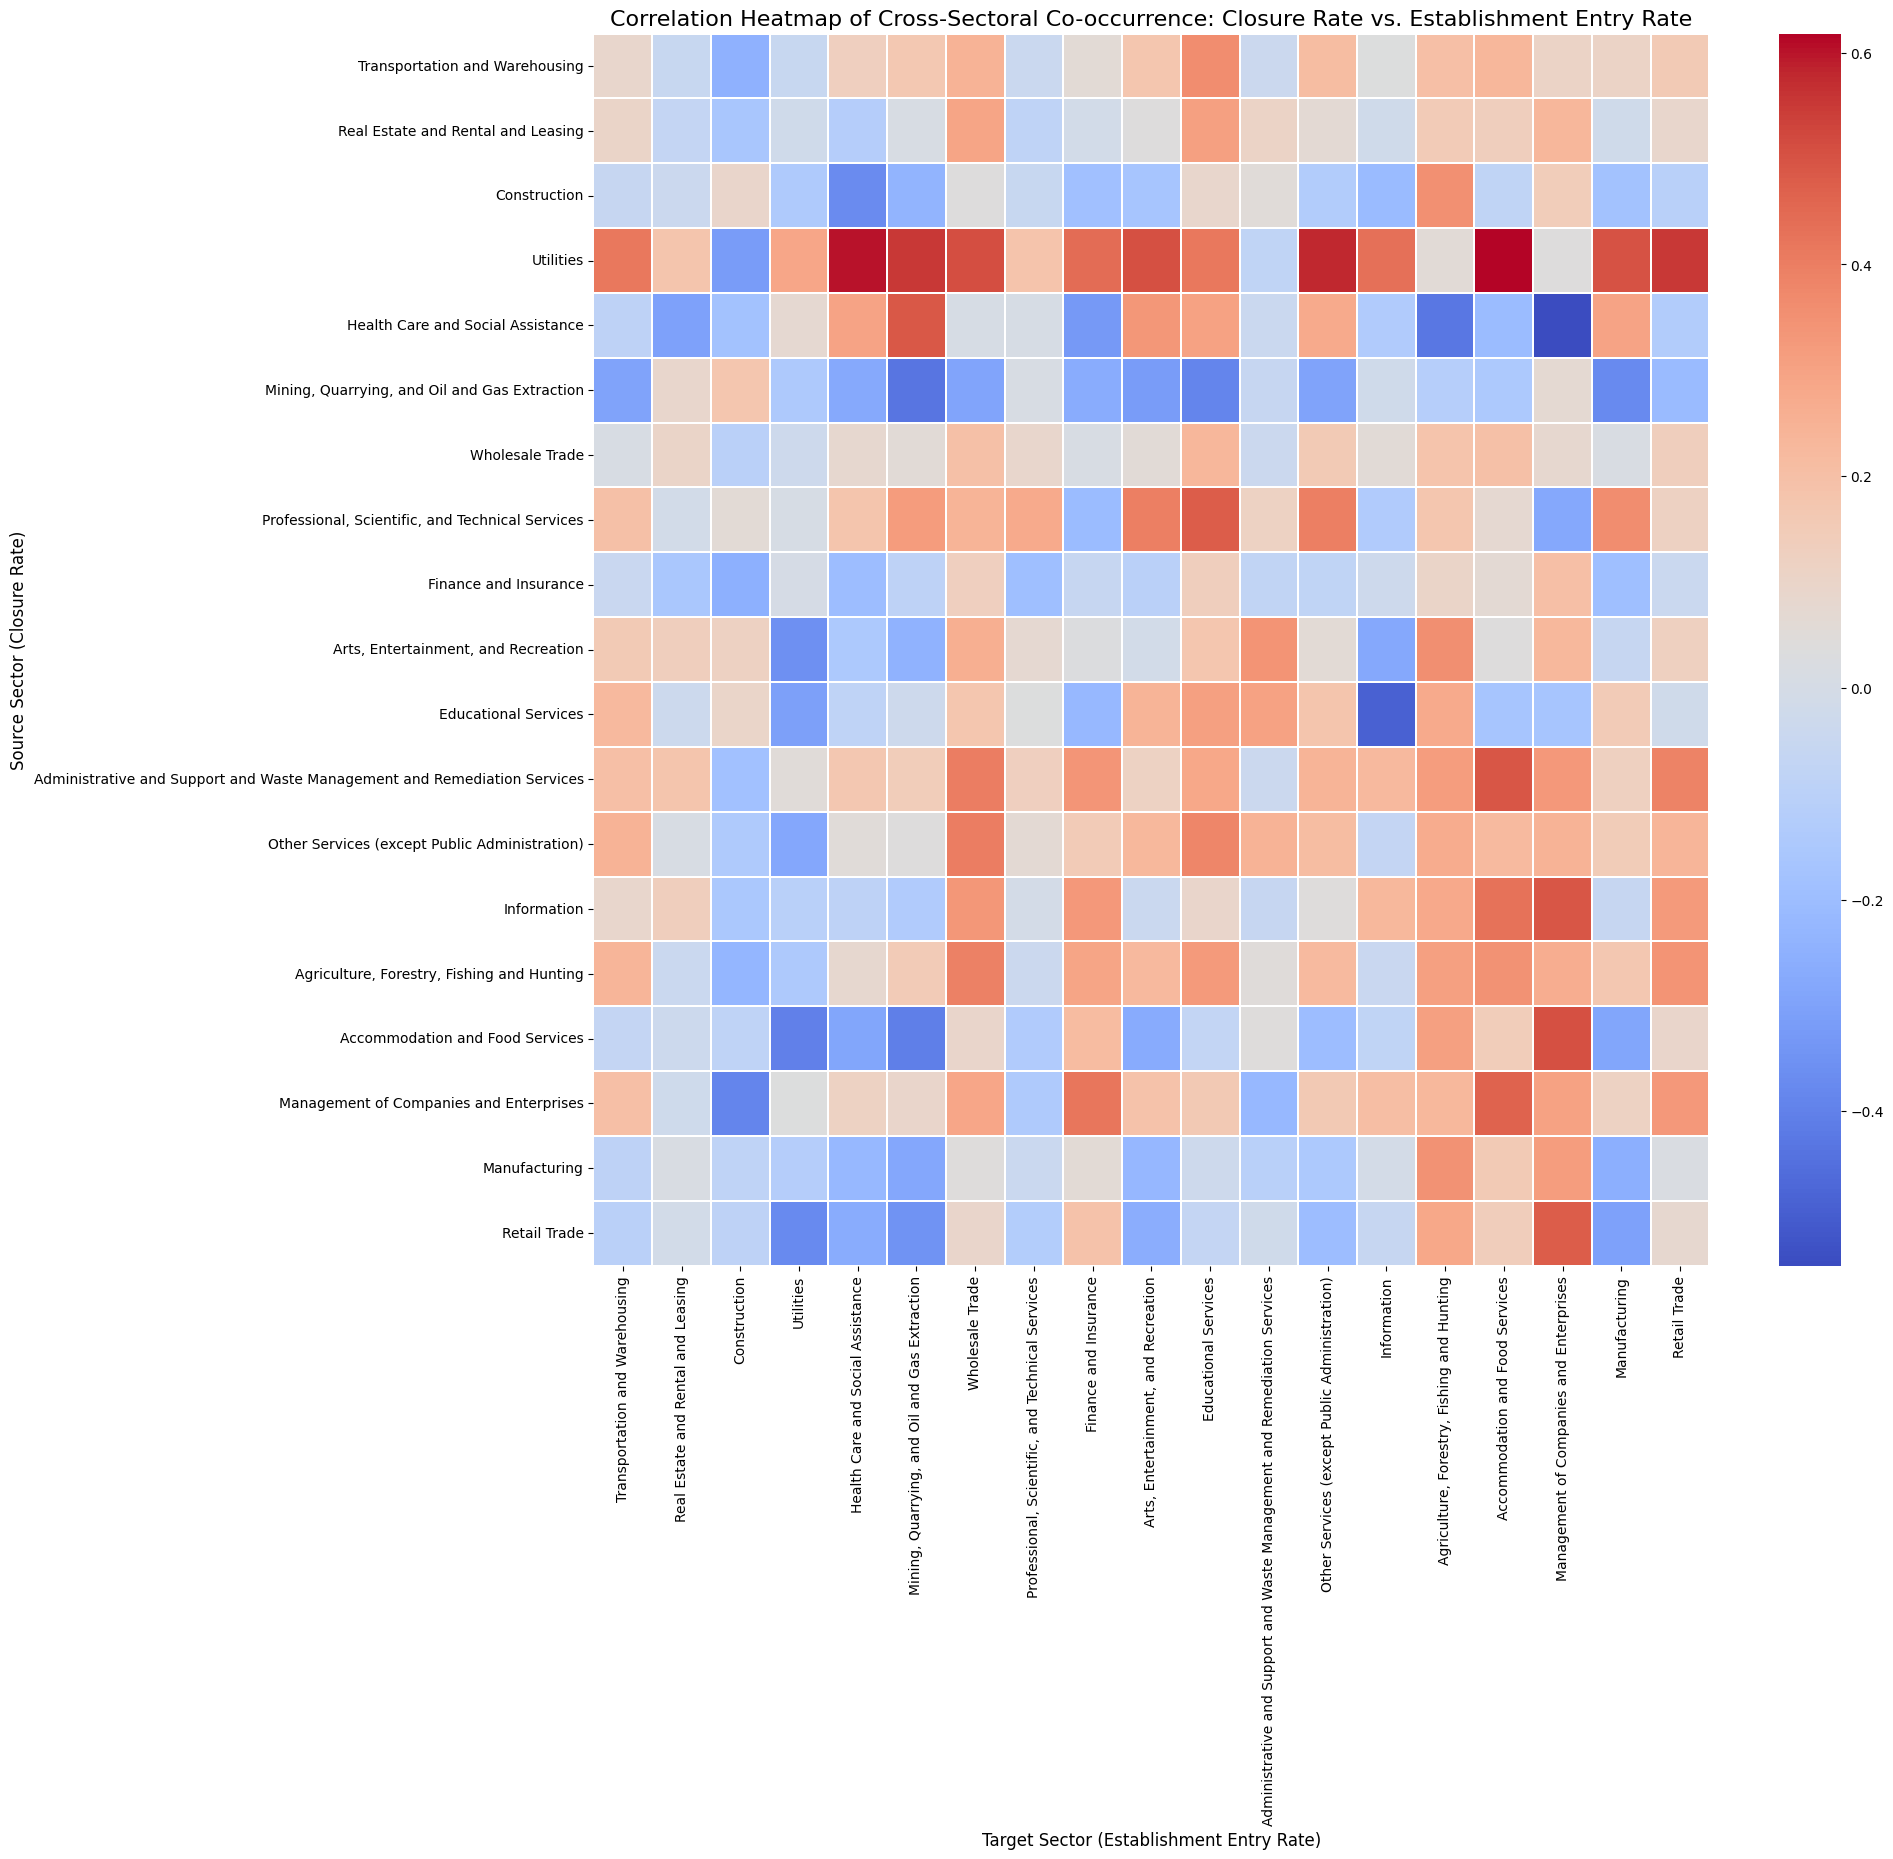

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a correlation heatmap for Cross-Sectoral Co-occurrence
plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix_closure_entry.astype(float), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Heatmap of Cross-Sectoral Co-occurrence: Closure Rate vs. Establishment Entry Rate', fontsize=16)
plt.xlabel('Target Sector (Establishment Entry Rate)', fontsize=12)
plt.ylabel('Source Sector (Closure Rate)', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.show()


Network Graph of Cross-Sectoral Co-occurrence (Closure vs. Entry)
Maximum cross-sectoral correlation found: 0.6181


/usr/local/lib/python3.12/dist-packages/netgraph/_edge_layout.py:751: UserWarning: Edge-bundling of self-loops not supported. Self-loops are removed from the edge list.
  warnings.warn('Edge-bundling of self-loops not supported. Self-loops are removed from the edge list.')
/usr/local/lib/python3.12/dist-packages/netgraph/_edge_layout.py:978: RuntimeWarning: invalid value encountered in divide
  displacement = compatibility * delta / distance_squared[..., None]


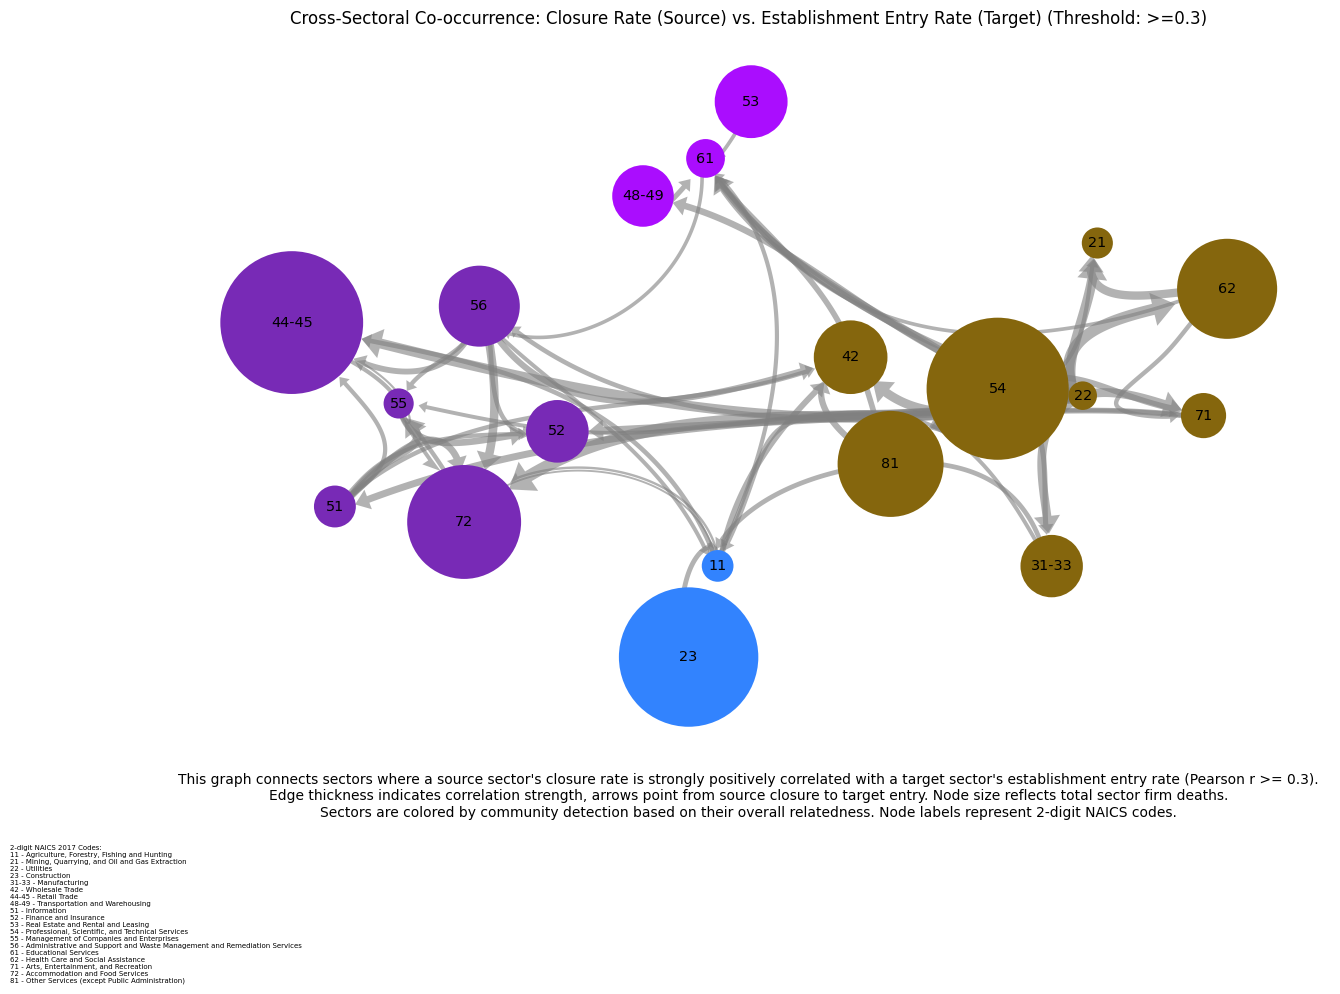

In [ ]:
import community.community_louvain as co
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
from netgraph import Graph # Importing Graph from netgraph
import plotly.express as px

print("\nNetwork Graph of Cross-Sectoral Co-occurrence (Closure vs. Entry)")

# Define a correlation threshold for creating edges
correlation_threshold_cross = 0.3 # Lowered threshold to ensure edges are created for visualization

# Print the maximum correlation value to understand the data range
max_cross_correlation = corr_matrix_closure_entry.max().max()
print(f"Maximum cross-sectoral correlation found: {max_cross_correlation:.4f}")

# Create edges based on the new cross-sectoral correlation matrix
correlation_edges_cross = []
for i in range(len(corr_matrix_closure_entry.index)):
    for j in range(len(corr_matrix_closure_entry.columns)): # Iterate through all cells, including asymmetric ones
        sector1 = corr_matrix_closure_entry.index[i]
        sector2 = corr_matrix_closure_entry.columns[j]
        correlation_value = corr_matrix_closure_entry.iloc[i, j]

        if pd.notna(correlation_value) and correlation_value >= correlation_threshold_cross:
            correlation_edges_cross.append({'u': sector1, 'v': sector2, 'weight': correlation_value})

# Calculating node sizes, indicating total firm deaths per sector (reusing from previous sector analysis)
sector_total_closures = df.groupby('sector_name')['firmdeath_firms'].sum()

# Creating the NetworkX graph
G_cross = nx.DiGraph() # Using a directed graph because the correlation is asymmetric (Closure A -> Entry B)
for edge in correlation_edges_cross:
    G_cross.add_edge(edge['u'], edge['v'], weight=edge['weight'])

# Filtering out sectors that are not connected in the graph (isolates)
isolates_cross = list(nx.isolates(G_cross))
G_cross.remove_nodes_from(isolates_cross)

# Community detection on the undirected version of the graph for node coloring (Louvain works best on undirected)
if G_cross.nodes():
    G_cross_undirected = G_cross.to_undirected()
    partition_cross = co.best_partition(G_cross_undirected)
    unique_communities_cross = sorted(list(set(partition_cross.values())))

    node_to_community_cross = partition_cross

    community_colors_palette_cross = px.colors.qualitative.Alphabet
    community_color_map_cross = {
        community_id: community_colors_palette_cross[i % len(community_colors_palette_cross)]
        for i, community_id in enumerate(unique_communities_cross)
    }

    node_color_cross = {node: community_color_map_cross[partition_cross[node]] for node in G_cross.nodes()}
else:
    print("No connected sectors found above the correlation threshold for cross-sectoral analysis.")
    partition_cross = {}
    node_to_community_cross = {}
    node_color_cross = {}

# Scaling node sizes for netgraph
filtered_sector_total_closures_cross = sector_total_closures[sector_total_closures.index.isin(G_cross.nodes())]

if not filtered_sector_total_closures_cross.empty and len(G_cross.nodes()) > 0:
    min_closures_cross = filtered_sector_total_closures_cross.min()
    max_closures_cross = filtered_sector_total_closures_cross.max()

    if max_closures_cross == min_closures_cross:
        node_size_by_cross = {sector: 5 for sector in G_cross.nodes()}
    else:
        node_size_by_cross = {sector: 2 + 8 * (closures - min_closures_cross) / (max_closures_cross - min_closures_cross)
                                for sector, closures in filtered_sector_total_closures_cross.items()}
else:
    node_size_by_cross = {} # Empty if no nodes or no closure data

# Creating edge widths based on correlation strength
edge_widths_cross = {}
for u, v, data in G_cross.edges(data=True):
    correlation_value = data['weight']
    scaled_width = 0.5 + (correlation_value - correlation_threshold_cross) * (2.5 / (1.0 - correlation_threshold_cross))
    edge_widths_cross[(u,v)] = scaled_width

# Preparing node labels (using NAICS codes, assuming `sector_to_naics` is available)
node_labels_cross = {node: sector_to_naics.get(node, node) for node in G_cross.nodes()}

fig_cross, ax_cross = plt.subplots(figsize=(15, 12))

# Only attempt to draw the graph if there are nodes/edges to display
if G_cross.number_of_nodes() > 0:
    Graph(G_cross,
          node_color=node_color_cross,
          node_edge_width=0,
          edge_width=edge_widths_cross,
          edge_alpha=0.6,
          node_layout='community', node_layout_kwargs=dict(node_to_community=node_to_community_cross),
          node_size=node_size_by_cross,
          node_labels=node_labels_cross,
          edge_layout='bundled', # Use bundled layout for potentially clearer visualization
          ax=ax_cross,
          edge_color='grey', # Default edge color
          arrows=True, # Display arrows for directed graph
          arrow_size=5
    )

    ax_cross.set_facecolor('white')

    ax_cross.set_title(f'Cross-Sectoral Co-occurrence: Closure Rate (Source) vs. Establishment Entry Rate (Target) (Threshold: >={correlation_threshold_cross})')
    plt.text(0.5, -0.05,
             f"This graph connects sectors where a source sector's closure rate is strongly positively correlated with a target sector's establishment entry rate (Pearson r >= {correlation_threshold_cross}).\nEdge thickness indicates correlation strength, arrows point from source closure to target entry. Node size reflects total sector firm deaths.\nSectors are colored by community detection based on their overall relatedness. Node labels represent 2-digit NAICS codes.",
             horizontalalignment='center',
             verticalalignment='center',
             transform=ax_cross.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # Re-add NAICS legend for reference
    naics_legend_text = "2-digit NAICS 2017 Codes:\n" + "\n".join([f"{code} - {name}" for code, name in naics_mapping.items()])
    plt.figtext(0.02, 0.005, naics_legend_text, fontsize=5, ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.show()
else:
    print("No nodes or edges to display in the graph after filtering and thresholding.")